In [17]:
import os
import sys
import traci
import sumolib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gymnasium as gym

In [18]:
# Path SUMO para la simulacion
if 'SUMO_HOME' not in os.environ:
    os.environ['SUMO_HOME'] = '/usr/share/sumo'
tools = os.path.join(os.environ['SUMO_HOME'], 'tools')
sys.path.append(tools)

# Usar libsumo (~8x mas rapido que traci puro)
os.environ['LIBSUMO_AS_TRACI'] = '1'

# Ejecutar simulacion
# sumo = no UI
# sumo-gui = UI
sumo_binary = sumolib.checkBinary('sumo') 
# Rutas de archivos de simulación
archivo_red = os.path.join("..", "..", "Simple_Intersection.net.xml")
archivo_rutas = os.path.join("..", "..", "Distribuciones", "Dist_Weibull_V2", "loja_intersection_weibull.rou.xml")
ruta_tripinfo = "resultados_tripinfo.xml"

sumo_cmd = [
    sumo_binary, 
    "-n", archivo_red,
    "-r", archivo_rutas,
    "--no-step-log", "true",
    "--tripinfo-output", ruta_tripinfo,
    "-W"
]

In [19]:
datos_simulacion = []
ventana_llegadas = []  # buffer de llegadas por paso

try:
    traci.start(sumo_cmd)
    while traci.simulation.getMinExpectedNumber() > 0:
        traci.simulationStep()
        step_actual = traci.simulation.getTime()
        vehiculos_ids = traci.vehicle.getIDList()
        num_vehiculos = len(vehiculos_ids)

        # llegada = vehiculos que entraron a la red desde el paso anterior
        arrival_step = traci.simulation.getDepartedNumber()  # vehiculos insertados en este paso (5s)
        ventana_llegadas.append(arrival_step)
        if len(ventana_llegadas) > 6:  # 6 pasos x 5s = 30s
            ventana_llegadas.pop(0)
        arrival_rate = sum(ventana_llegadas)

        if num_vehiculos > 0:
            velocidades = [traci.vehicle.getSpeed(v) for v in vehiculos_ids]
            vehiculos_en_cola = sum(1 for v in velocidades if v < 0.1)
            tiempos_espera = [traci.vehicle.getWaitingTime(v) for v in vehiculos_ids]
            tiempos_perdidos = [traci.vehicle.getTimeLoss(v) for v in vehiculos_ids]

            datos_simulacion.append({
                "Paso_Tiempo": step_actual,
                "Vehiculos_Activos": num_vehiculos,
                "Cola_Actual": vehiculos_en_cola,
                "Velocidad_Min": np.min(velocidades),
                "Velocidad_Max": np.max(velocidades),
                "Velocidad_Promedio": np.mean(velocidades),
                "TiempoEspera_Promedio": np.mean(tiempos_espera),
                "TiempoPerdido_Promedio": np.mean(tiempos_perdidos),
                "Arrival_Rate": arrival_rate,  # NUEVO
            })
finally:
    traci.close()

df_metricas = pd.DataFrame(datos_simulacion)
print("Simulación finalizada. Datos recolectados:", len(df_metricas), "pasos.")
ruta_csv_seguro = "datasets/qlearning_dataset_sumo.csv"
os.makedirs(os.path.dirname(ruta_csv_seguro), exist_ok=True)
df_metricas.to_csv(ruta_csv_seguro, index=False)

 Retrying in 1 seconds
Simulación finalizada. Datos recolectados: 3539 pasos.


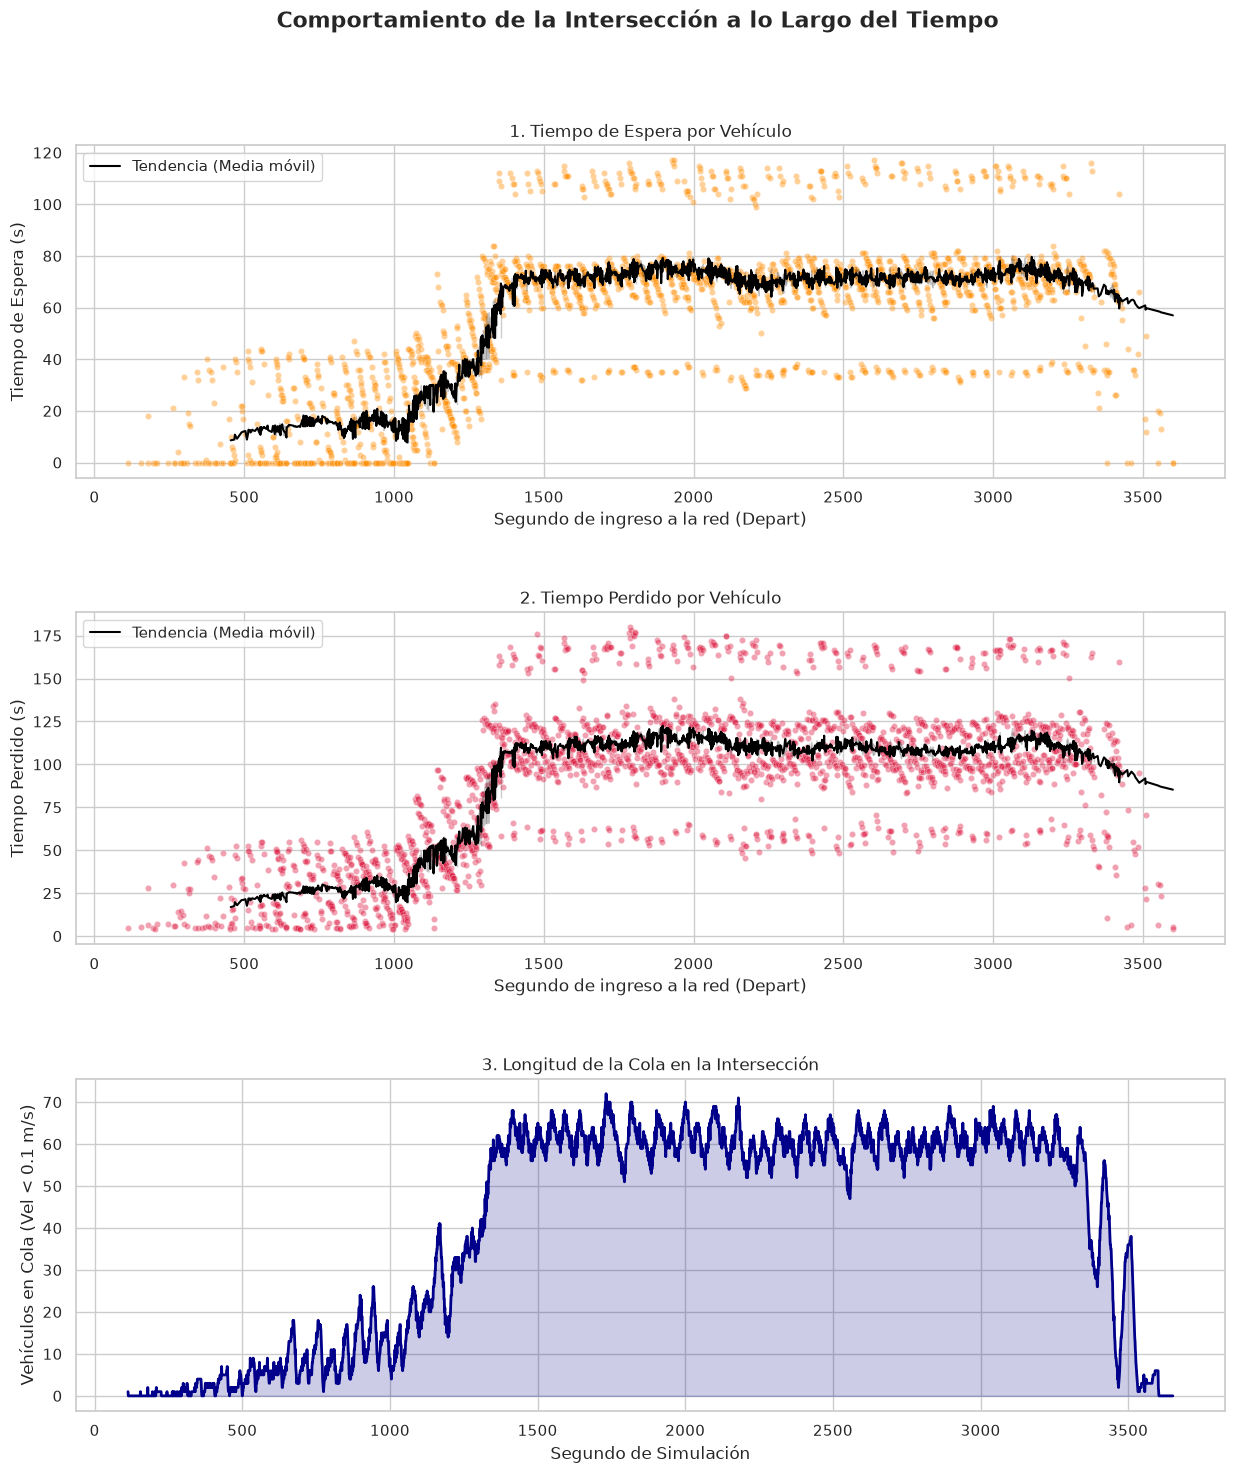

In [20]:
# 1. Configuración de estilo
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# 2. Cargar datos de vehículos
ruta_xml = "resultados_tripinfo.xml"
df_trips = pd.read_xml(ruta_xml)

# Convertir columnas a numéricas
for col in ['depart', 'waitingTime', 'timeLoss']:
    df_trips[col] = pd.to_numeric(df_trips[col])

# 3. Crear el lienzo con 3 subgráficas verticales
fig, axs = plt.subplots(3, 1, figsize=(14, 15))
fig.tight_layout(pad=6.0) # Espacio para que no se superpongan los textos
fig.suptitle('Comportamiento de la Intersección a lo Largo del Tiempo', fontsize=16, fontweight='bold', y=1.02)

# --- GRÁFICA 1: Tiempo de Espera de CADA vehículo ---
sns.scatterplot(x=df_trips['depart'], y=df_trips['waitingTime'], alpha=0.4, color='darkorange', s=20, ax=axs[0])
# Solución al error: Pasamos la serie df_trips['depart'] directamente
sns.lineplot(x=df_trips['depart'], y=df_trips['waitingTime'].rolling(50).mean(), color='black', label='Tendencia (Media móvil)', ax=axs[0])
axs[0].set_title("1. Tiempo de Espera por Vehículo")
axs[0].set_xlabel("Segundo de ingreso a la red (Depart)")
axs[0].set_ylabel("Tiempo de Espera (s)")
axs[0].legend()

# --- GRÁFICA 2: Tiempo Perdido de CADA vehículo ---
sns.scatterplot(x=df_trips['depart'], y=df_trips['timeLoss'], alpha=0.4, color='crimson', s=20, ax=axs[1])
sns.lineplot(x=df_trips['depart'], y=df_trips['timeLoss'].rolling(50).mean(), color='black', label='Tendencia (Media móvil)', ax=axs[1])
axs[1].set_title("2. Tiempo Perdido por Vehículo")
axs[1].set_xlabel("Segundo de ingreso a la red (Depart)")
axs[1].set_ylabel("Tiempo Perdido (s)")
axs[1].legend()

# --- GRÁFICA 3: Longitud de la Cola a lo largo del tiempo ---
# Asegúrate de haber ejecutado antes la celda de TraCI que genera df_metricas
if 'df_metricas' in locals():
    axs[2].plot(df_metricas['Paso_Tiempo'], df_metricas['Cola_Actual'], color='darkblue', linewidth=2)
    axs[2].fill_between(df_metricas['Paso_Tiempo'], df_metricas['Cola_Actual'], color='darkblue', alpha=0.2)
    axs[2].set_title("3. Longitud de la Cola en la Intersección")
    axs[2].set_xlabel("Segundo de Simulación")
    axs[2].set_ylabel("Vehículos en Cola (Vel < 0.1 m/s)")
else:
    axs[2].text(0.5, 0.5, 'Requiere el DataFrame df_metricas generado por TraCI', horizontalalignment='center', fontsize=12)
    axs[2].set_title("3. Longitud de la Cola en la Intersección")

plt.show()

In [21]:
# Asegurar tipo numérico
for col in ['waitingTime', 'timeLoss', 'routeLength', 'duration']:
    df_trips[col] = pd.to_numeric(df_trips[col])

# Calcular velocidad efectiva por vehículo (km/h)
df_trips['velocidad_kmh'] = (df_trips['routeLength'] / df_trips['duration']) * 3.6

# Métricas por paso de tiempo

# Cálculo de variables
promedio_espera = df_trips['waitingTime'].mean()
maximo_espera = df_trips['waitingTime'].max()

promedio_perdido = df_trips['timeLoss'].mean()
maximo_perdido = df_trips['timeLoss'].max()

velocidad_media_global = df_trips['velocidad_kmh'].mean()
total_vehiculos = len(df_trips)

cola_promedio = df_metricas['Cola_Actual'].mean()
cola_maxima = df_metricas['Cola_Actual'].max()

# Impresión de resultados
print("="*50)
print("  REPORTE DE MÉTRICAS: LÍNEA BASE (TIEMPOS FIJOS)")
print("="*50)
print("\n--- Rendimiento General ---")
print(f"Total de vehículos procesados : {total_vehiculos}")
print(f"Velocidad promedio del sistema: {velocidad_media_global:.2f} km/h")

print("\n--- Demora Vehicular (Tripinfo) ---")
print(f"Tiempo de espera promedio     : {promedio_espera:.2f} s")
print(f"Tiempo de espera MÁXIMO       : {maximo_espera:.2f} s")
print(f"Tiempo perdido promedio       : {promedio_perdido:.2f} s")
print(f"Tiempo perdido MÁXIMO         : {maximo_perdido:.2f} s")
ventana_llegadas.append(arrival_step)
if len(ventana_llegadas) > 6:  # 6 pasos x 5s = 30s de ventana
    ventana_llegadas.pop(0)
arrival_rate = sum(ventana_llegadas)
print("\n--- Ocupación de la Intersección (TraCI) ---")
print(f"Longitud de cola promedio     : {cola_promedio:.2f} vehículos")
print(f"Longitud de cola MÁXIMA       : {cola_maxima} vehículos")
print("="*50)

# Vista de los primeros valores del dataset
display(df_trips[['id', 'depart', 'duration', 'waitingTime', 'timeLoss']].head())

  REPORTE DE MÉTRICAS: LÍNEA BASE (TIEMPOS FIJOS)

--- Rendimiento General ---
Total de vehículos procesados : 2418
Velocidad promedio del sistema: 18.17 km/h

--- Demora Vehicular (Tripinfo) ---
Tiempo de espera promedio     : 57.63 s
Tiempo de espera MÁXIMO       : 117.00 s
Tiempo perdido promedio       : 89.80 s
Tiempo perdido MÁXIMO         : 180.00 s

--- Ocupación de la Intersección (TraCI) ---
Longitud de cola promedio     : 40.06 vehículos
Longitud de cola MÁXIMA       : 72 vehículos


,id,depart,duration,waitingTime,timeLoss
0,veh_0,112.0,49.0,0.0,4.92
1,veh_1,154.0,52.0,0.0,5.01
2,veh_2,179.0,51.0,0.0,6.48
3,veh_4,195.0,49.0,0.0,4.79
4,veh_3,179.0,72.0,18.0,27.77


In [22]:
import pandas as pd

df_check = pd.read_csv("datasets/qlearning_dataset_sumo.csv")
print(df_check.columns.tolist())
print(df_check["Arrival_Rate"].describe())
print(df_check["Arrival_Rate"].value_counts().head(10))

['Paso_Tiempo', 'Vehiculos_Activos', 'Cola_Actual', 'Velocidad_Min', 'Velocidad_Max', 'Velocidad_Promedio', 'TiempoEspera_Promedio', 'TiempoPerdido_Promedio', 'Arrival_Rate']
count    3539.000000
mean        4.099463
std         2.269255
min         0.000000
25%         3.000000
50%         4.000000
75%         6.000000
max        11.000000
Name: Arrival_Rate, dtype: float64
Arrival_Rate
4    955
5    575
6    385
0    352
7    285
3    282
1    247
2    222
8    164
9     63
Name: count, dtype: int64


In [23]:
"""
Recalibracion de bins usando percentiles del dataset de baseline real
(tiempo fijo), en vez de rangos genericos del paper.
"""
import numpy as np
import pandas as pd
import os

df_metricas = pd.read_csv("datasets/qlearning_dataset_sumo.csv")

def bin_edges(datos, n_bins):
    percentiles = np.linspace(0, 100, n_bins + 1)[1:-1]
    return np.percentile(datos, percentiles)

EDGES_NVEHICULOS = bin_edges(df_metricas["Vehiculos_Activos"], 6)
EDGES_WAITING    = bin_edges(df_metricas["TiempoEspera_Promedio"], 6)
EDGES_QUEUE      = bin_edges(df_metricas["Cola_Actual"], 4)
EDGES_ARRIVAL    = bin_edges(df_metricas["Arrival_Rate"], 3)

print("=" * 56)
print("  EDGES CALIBRADOS CON TRAFICO REAL (tiempo fijo)")
print("=" * 56)
print(f"nvehiculos (6 bins): {np.round(EDGES_NVEHICULOS, 1)}")
print(f"waiting    (6 bins): {np.round(EDGES_WAITING, 1)}")
print(f"queue      (4 bins): {np.round(EDGES_QUEUE, 1)}")
print(f"arrival    (3 bins): {np.round(EDGES_ARRIVAL, 1)}")
print("=" * 56)

os.makedirs("resultados", exist_ok=True)
np.savez(
    "resultados/bin_edges_calibrados.npz",
    nvehiculos=EDGES_NVEHICULOS,
    waiting=EDGES_WAITING,
    queue=EDGES_QUEUE,
    arrival=EDGES_ARRIVAL,
)
print("\nEdges guardados en resultados/bin_edges_calibrados.npz")

  EDGES CALIBRADOS CON TRAFICO REAL (tiempo fijo)
nvehiculos (6 bins): [ 30.   74.3 128.  131.  133. ]
waiting    (6 bins): [1.6 5.7 7.9 8.3 9. ]
queue      (4 bins): [10. 56. 61.]
arrival    (3 bins): [4. 5.]

Edges guardados en resultados/bin_edges_calibrados.npz
